# Uploading Models with KerasHub

**Author:** [Samaneh Saadat](https://github.com/SamanehSaadat/), [Matthew Watson](https://github.com/mattdangerw/)<br>
**Date created:** 2024/04/29<br>
**Last modified:** 2024/04/29<br>
**Description:** An introduction on how to upload a fine-tuned KerasHub model to model hubs.

# Introduction

Fine-tuning a machine learning model can yield impressive results for specific tasks.
Uploading your fine-tuned model to a model hub allows you to share it with the broader community.
By sharing your models, you'll enhance accessibility for other researchers and developers,
making your contributions an integral part of the machine learning landscape.
This can also streamline the integration of your model into real-world applications.

This guide walks you through how to upload your fine-tuned models to popular model hubs such as
[Kaggle Models](https://www.kaggle.com/models) and [Hugging Face Hub](https://huggingface.co/models).

# Setup

Let's start by installing and importing all the libraries we need. We use KerasHub for this guide.

In [9]:
!pip install -q --upgrade keras-hub huggingface-hub kagglehub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 79.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 671.5/671.5 kB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 8.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-nlp 0.26.0 requires keras-hub==0.26.0, but you have keras-hub 0.29.1 which is incompatible.


In [10]:
import os

os.environ["KERAS_BACKEND"] = "jax"

import keras_hub

In [ ]:
!pip install -q --upgrade keras-hub huggingface-hub kagglehub

In [ ]:
import os

os.environ["KERAS_BACKEND"] = "jax"

import keras_hub

In [15]:
import keras_hub

# Data

We can use the IMDB reviews dataset for this guide. Let's load the dataset from `tensorflow_dataset`.

In [3]:
import tensorflow_datasets as tfds

imdb_train, imdb_test = tfds.load(
    "imdb_reviews",
    split=["train", "test"],
    as_supervised=True,
    batch_size=4,
)

In [12]:
causal_lm = keras_hub.models.CausalLM.from_preset("gpt2_base_en")

In [7]:
causal_lm = keras_hub.models.CausalLM.from_preset("gpt2_base_en")

NameError: name 'keras_hub' is not defined

We only use a small subset of the training samples to make the guide run faster.
However, if you need a higher quality model, consider using a larger number of training samples.

# Task Upload

A `keras_hub.models.Task`, wraps a `keras_hub.models.Backbone` and a `keras_hub.models.Preprocessor` to create
a model that can be directly used for training, fine-tuning, and prediction for a given text problem.
In this section, we explain how to create a `Task`, fine-tune and upload it to a model hub.

In [6]:
imdb_train = imdb_train.take(100)

## Load Model

If you want to build a Causal LM based on a base model, simply call `keras_hub.models.CausalLM.from_preset`
and pass a built-in preset identifier.

## Fine-tune Model

After loading the model, you can call `.fit()` on the model to fine-tune it.
Here, we fine-tune the model on the IMDB reviews which makes the model movie domain-specific.

In [ ]:
# Drop labels and keep the review text only for the Causal LM.
imdb_train_reviews = imdb_train.map(lambda x, y: x)

# Fine-tune the Causal LM.
causal_lm.fit(imdb_train_reviews)

In [13]:
# imdb_train 데이터셋의 element_spec 확인
print("imdb_train element_spec:", imdb_train.element_spec)

# 첫 번째 배치에서 샘플 데이터 확인
for text_batch, label_batch in imdb_train.take(1):
    print("\nSample text from the first batch:", text_batch[0].numpy().decode('utf-8'))
    print("Sample label from the first batch:", label_batch[0].numpy())
    break

imdb_train element_spec: (TensorSpec(shape=(None,), dtype=tf.string, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))

Sample text from the first batch: This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it.
Sample label from the first batch: 0


In [14]:
import tensorflow as tf

# Causal LM 학습을 위해 레이블을 제외하고 텍스트만 추출합니다.
imdb_train_texts = imdb_train.map(lambda text, label: text)

# 1 에포크 동안 학습을 수행합니다.
causal_lm.fit(imdb_train_texts, epochs=1)

100/100 ━━━━━━━━━━━━━━━━━━━━ 200s 1s/step - loss: 1.0200 - sparse_categorical_accuracy: 0.3316


### Text Generation Test

Let's test our fine-tuned GPT-2 model to see if it has learned to generate text in the style of IMDB movie reviews.

In [16]:
prompt = "This movie was"
output = causal_lm.generate(prompt, max_length=100)
print(output)

This movie was very good, I think. I loved it. It's a very good film. It's about a guy who's trying to get into a business and gets caught up with his family and friends. The story is very interesting, but the plot itself doesn't make sense. There are some things that are interesting that are hidden, but the plot is just too boring. It's not a good movie at all. It's not good at all. I think I'm going to


### Improving Generation Quality with Sampling

By default, generation might be repetitive. We can use `sampler` arguments to make the output more natural. `top_p` and `temperature` are commonly used for fine-tuned LLMs.

In [19]:
# To improve quality, we compile the model with a specific sampler
causal_lm.compile(sampler=keras_hub.samplers.TopPSampler(p=0.9, temperature=0.7))

# Now we generate without passing 'sampler' to the generate call
output_tuned = causal_lm.generate(
    "This movie was",
    max_length=100
)

print("--- Tuned Generation (Top-P) ---")
print(output_tuned)

--- Tuned Generation (Top-P) ---
This movie was one of the first I saw in theaters and I was so excited to see it again. I had never seen it before so I knew I wanted to see it again. I was about to go back to the theater and it was still pretty dark and the lights were dimmer. I had to wait for the director to come out to see it. I was very disappointed that it had to be in such darkness. I felt like I was in a nightmare and I wanted to scream


### 모델 저장하기

학습이 완료된 모델을 `save_to_preset`을 사용하여 로컬 디렉토리에 저장합니다.

In [20]:
# 저장할 디렉토리 경로 설정
preset_dir = "./my_finetuned_gpt2"

# 모델 저장
causal_lm.save_to_preset(preset_dir)

print(f"모델이 '{preset_dir}' 경로에 저장되었습니다.")
# 저장된 파일 목록 확인
import os
print("저장된 파일:", os.listdir(preset_dir))

모델이 './my_finetuned_gpt2' 경로에 저장되었습니다.
저장된 파일: ['metadata.json', 'model.weights.h5', 'config.json', 'preprocessor.json', 'tokenizer.json', 'task.json', 'assets']


### Kaggle에 모델 업로드하기

Kaggle에 모델을 올리려면 먼저 Kaggle API 인증이 필요합니다. 아래 셀을 실행하여 로그인하고 업로드를 진행하세요.

In [25]:
import kagglehub
import os

# 1단계: 이 셀을 실행하고 나타나는 위젯에 Kaggle 계정 정보를 입력하세요.
# 로그인 버튼을 누른 후 'Kaggle credentials set' 메시지를 확인해야 합니다.
kagglehub.login()

Kaggle credentials set.
Unable to validate Kaggle credentials at this time.


## Save the Model Locally

To upload a model, you need to first save the model locally using `save_to_preset`.

In [ ]:
preset_dir = "./gpt2_imdb"
causal_lm.save_to_preset(preset_dir)

Let's see the saved files.

In [ ]:
os.listdir(preset_dir)

### Load a Locally Saved Model

A model that is saved to a local preset can be loaded using `from_preset`.
What you save in, is what you get back out.

In [ ]:
causal_lm = keras_hub.models.CausalLM.from_preset(preset_dir)

You can also load the `keras_hub.models.Backbone` and `keras_hub.models.Tokenizer` objects from this preset directory.
Note that these objects are equivalent to `causal_lm.backbone` and `causal_lm.preprocessor.tokenizer` above.

In [ ]:
backbone = keras_hub.models.Backbone.from_preset(preset_dir)
tokenizer = keras_hub.models.Tokenizer.from_preset(preset_dir)

## Upload the Model to a Model Hub

After saving a preset to a directory, this directory can be uploaded to a model hub such as Kaggle or Hugging Face directly from the KerasHub library.
To upload the model to Kaggle, the URI must start with `kaggle://` and to upload to Hugging Face, it should start with `hf://`.

### Upload to Kaggle

To upload a model to Kaggle, first, we need to authenticate with Kaggle.
This can in one of the following ways:
1. Set environment variables `KAGGLE_USERNAME` and `KAGGLE_KEY`.
2. Provide a local `~/.kaggle/kaggle.json`.
3. Call `kagglehub.login()`.

Let's make sure we are logged in before continuing.

In [ ]:
import kagglehub

if "KAGGLE_USERNAME" not in os.environ or "KAGGLE_KEY" not in os.environ:
    kagglehub.login()

To upload a model we can use `keras_hub.upload_preset(uri, preset_dir)` API where `uri` has the format of
`kaggle://<KAGGLE_USERNAME>/<MODEL>/Keras/<VARIATION>` for uploading to Kaggle and `preset_dir` is the directory that the model is saved in.

Running the following uploads the model that is saved in `preset_dir` to Kaggle:

In [28]:
import keras_hub
import kagglehub

# 2단계: 로그인이 완료되었으므로 업로드를 수행합니다.
try:
    user_info = kagglehub.whoami()
    kaggle_username = user_info["username"]
    print(f"인증 확인됨: {kaggle_username}")

    # 업로드 설정
    model_name = "gpt2-imdb-finetuned"
    variation_name = "v1"
    kaggle_uri = f"kaggle://{kaggle_username}/{model_name}/keras/{variation_name}"
    # 앞서 저장한 모델 경로 사용
    current_preset_dir = "./my_finetuned_gpt2"

    print(f"'{current_preset_dir}'의 모델을 {kaggle_uri}로 업로드 중...")
    keras_hub.upload_preset(kaggle_uri, current_preset_dir)
    print("🎉 업로드가 완료되었습니다! Kaggle Model Hub에서 확인해 보세요.")

except Exception as e:
    print(f"업로드 중 오류 발생: {e}")

Kaggle credentials successfully validated.
인증 확인됨: sinavro
'./my_finetuned_gpt2'의 모델을 kaggle://sinavro/gpt2-imdb-finetuned/keras/v1로 업로드 중...
Uploading Model https://api.kaggle.com/models/sinavro/gpt2-imdb-finetuned/keras/v1 ...
Model 'gpt2-imdb-finetuned' does not exist or access is forbidden for user 'sinavro'. Creating or handling Model...
Model 'gpt2-imdb-finetuned' Created.
Starting upload for file ./my_finetuned_gpt2/metadata.json


Uploading: 100%|██████████| 184/184 [00:00<00:00, 213B/s]

Upload successful: ./my_finetuned_gpt2/metadata.json (184B)
Starting upload for file ./my_finetuned_gpt2/model.weights.h5



Uploading: 100%|██████████| 498M/498M [00:26<00:00, 18.7MB/s]

Upload successful: ./my_finetuned_gpt2/model.weights.h5 (475MB)
Starting upload for file ./my_finetuned_gpt2/config.json


...


Uploading: 100%|██████████| 1.04M/1.04M [00:02<00:00, 447kB/s]

Upload successful: ./my_finetuned_gpt2/assets/tokenizer/vocabulary.json (1018KB)
Starting upload for file ./my_finetuned_gpt2/assets/tokenizer/merges.txt



Uploading: 100%|██████████| 456k/456k [00:01<00:00, 229kB/s]

Upload successful: ./my_finetuned_gpt2/assets/tokenizer/merges.txt (446KB)


Your model instance has been created.
Files are being processed...
See at: https://api.kaggle.com/models/sinavro/gpt2-imdb-finetuned/keras/v1
🎉 업로드가 완료되었습니다! Kaggle Model Hub에서 확인해 보세요.


In [27]:
import kagglehub

# Kaggle 인증을 다시 수행합니다.
# 위젯이 나타나면 정보를 입력하고 반드시 'Login' 버튼을 클릭하세요.
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


### Upload to Hugging Face

To upload a model to Hugging Face, first, we need to authenticate with Hugging Face.
This can in one of the following ways:
1. Set environment variables `HF_USERNAME` and `HF_TOKEN`.
2. Call `huggingface_hub.notebook_login()`.

Let's make sure we are logged in before coninuing.

In [ ]:
import huggingface_hub

if "HF_USERNAME" not in os.environ or "HF_TOKEN" not in os.environ:
    huggingface_hub.notebook_login()

`keras_hub.upload_preset(uri, preset_dir)` can be used to upload a model to Hugging Face if `uri` has the format of
`kaggle://<HF_USERNAME>/<MODEL>`.

Running the following uploads the model that is saved in `preset_dir` to Hugging Face:

In [ ]:
hf_username = huggingface_hub.whoami()["name"]
hf_uri = f"hf://{hf_username}/gpt2_imdb"
keras_hub.upload_preset(hf_uri, preset_dir)

### Hugging Face Hub 로그인

Hugging Face에 모델을 업로드하거나 비공개 모델을 불러오려면 인증이 필요합니다. [Hugging Face Settings](https://huggingface.co/settings/tokens)에서 토큰을 생성한 뒤 아래 셀을 실행하여 입력해 주세요.

In [29]:
from huggingface_hub import notebook_login

# Hugging Face 로그인 위젯 호출
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [30]:
import huggingface_hub
import keras_hub

try:
    # Get the logged-in user's name
    hf_username = huggingface_hub.whoami()["name"]
    print(f"Authenticated as: {hf_username}")

    # Set the model identifier
    model_id = "gpt2-imdb-finetuned"
    hf_uri = f"hf://{hf_username}/{model_id}"

    # Use the existing preset directory we saved earlier
    current_preset_dir = "./my_finetuned_gpt2"

    print(f"Uploading model from '{current_preset_dir}' to '{hf_uri}'...")
    keras_hub.upload_preset(hf_uri, current_preset_dir)
    print(f"\u2728 Successfully uploaded to: https://huggingface.co/{hf_username}/{model_id}")

except Exception as e:
    print(f"An error occurred during upload: {e}")

An error occurred during upload: Token is required to call the /whoami-v2 endpoint, but no token found. You must provide a token or be logged in to Hugging Face with `hf auth login` or `huggingface_hub.login`. See https://huggingface.co/settings/tokens.


In [31]:
from huggingface_hub import notebook_login

# This will open a widget to enter your Hugging Face Access Token
notebook_login()

In [32]:
import huggingface_hub
import keras_hub

try:
    # Get the logged-in user's name
    user_info = huggingface_hub.whoami()
    hf_username = user_info["name"]
    print(f"Authenticated as: {hf_username}")

    # Set the model identifier
    model_id = "gpt2-imdb-finetuned"
    hf_uri = f"hf://{hf_username}/{model_id}"

    # Use the existing preset directory we saved earlier
    current_preset_dir = "./my_finetuned_gpt2"

    print(f"Uploading model from '{current_preset_dir}' to '{hf_uri}'...")
    keras_hub.upload_preset(hf_uri, current_preset_dir)
    print(f"\u2728 Successfully uploaded to: https://huggingface.co/{hf_username}/{model_id}")

except Exception as e:
    print(f"An error occurred: {e}")
    print("Make sure you have successfully logged in using the notebook_login() widget above before running this cell.")

An error occurred: Token is required to call the /whoami-v2 endpoint, but no token found. You must provide a token or be logged in to Hugging Face with `hf auth login` or `huggingface_hub.login`. See https://huggingface.co/settings/tokens.
Make sure you have successfully logged in using the notebook_login() widget above before running this cell.


In [33]:
import huggingface_hub
import keras_hub

try:
    # Get the logged-in user's name from Hugging Face
    user_info = huggingface_hub.whoami()
    hf_username = user_info["name"]
    print(f"Authenticated as: {hf_username}")

    # Set the repository name and URI
    model_id = "gpt2-imdb-finetuned"
    hf_uri = f"hf://{hf_username}/{model_id}"

    # The local directory where your model was saved earlier
    local_preset_dir = "./my_finetuned_gpt2"

    print(f"Uploading model to {hf_uri}...")
    # Upload the preset to Hugging Face Hub
    keras_hub.upload_preset(hf_uri, local_preset_dir)

    print(f"\u2728 Successfully uploaded! View your model here: https://huggingface.co/{hf_username}/{model_id}")

except Exception as e:
    print(f"An error occurred during upload: {e}")
    print("Please ensure you have completed the 'notebook_login()' step successfully.")

An error occurred during upload: Token is required to call the /whoami-v2 endpoint, but no token found. You must provide a token or be logged in to Hugging Face with `hf auth login` or `huggingface_hub.login`. See https://huggingface.co/settings/tokens.
Please ensure you have completed the 'notebook_login()' step successfully.


## Load a User Uploaded Model

After verifying that the model is uploaded to Kaggle, we can load the model by calling `from_preset`.

```python
causal_lm = keras_hub.models.CausalLM.from_preset(
    f"kaggle://{kaggle_username}/gpt2/keras/gpt2_imdb"
)
```

We can also load the model uploaded to Hugging Face by calling `from_preset`.

```python
causal_lm = keras_hub.models.CausalLM.from_preset(f"hf://{hf_username}/gpt2_imdb")
```

# Classifier Upload

Uploading a classifier model is similar to Causal LM upload.
To upload the fine-tuned model, first, the model should be saved to a local directory using `save_to_preset`
API and then it can be uploaded via `keras_hub.upload_preset`.

In [ ]:
# Load the base model.
classifier = keras_hub.models.Classifier.from_preset(
    "bert_tiny_en_uncased", num_classes=2
)

# Fine-tune the classifier.
classifier.fit(imdb_train)

# Save the model to a local preset directory.
preset_dir = "./bert_tiny_imdb"
classifier.save_to_preset(preset_dir)

# Upload to Kaggle.
keras_hub.upload_preset(
    f"kaggle://{kaggle_username}/bert/keras/bert_tiny_imdb", preset_dir
)

After verifying that the model is uploaded to Kaggle, we can load the model by calling `from_preset`.

```python
classifier = keras_hub.models.Classifier.from_preset(
    f"kaggle://{kaggle_username}/bert/keras/bert_tiny_imdb"
)
```

In [34]:
from huggingface_hub import notebook_login

# Open the Hugging Face login widget
notebook_login()

In [35]:
import huggingface_hub
import keras_hub

try:
    # This will work once you have logged in via the widget above
    user_info = huggingface_hub.whoami()
    hf_username = user_info["name"]

    model_id = "gpt2-imdb-finetuned"
    hf_uri = f"hf://{hf_username}/{model_id}"
    local_preset_dir = "./my_finetuned_gpt2"

    print(f"Uploading model to {hf_uri}...")
    keras_hub.upload_preset(hf_uri, local_preset_dir)
    print(f"\u2728 Successfully uploaded to: https://huggingface.co/{hf_username}/{model_id}")

except Exception as e:
    print(f"Upload failed: {e}")
    print("Make sure you have successfully logged in using the widget above.")

Uploading model to hf://hinttt/gpt2-imdb-finetuned...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ned_gpt2/model.weights.h5:   0%|          |  552kB /  498MB            

✨ Successfully uploaded to: https://huggingface.co/hinttt/gpt2-imdb-finetuned


### Inference Test with Hugging Face Model

Now that the model is uploaded, let's test if we can load it directly from the Hugging Face Hub and generate some text.

In [36]:
import keras_hub

# Define the Hugging Face URI
hf_model_uri = "hf://hinttt/gpt2-imdb-finetuned"

# Load the model from the Hub
print(f"Loading model from {hf_model_uri}...")
reloaded_lm = keras_hub.models.CausalLM.from_preset(hf_model_uri)

# Run a test generation
test_prompt = "The acting in this movie was"
output = reloaded_lm.generate(test_prompt, max_length=100)

print("\n--- Inference Output ---")
print(output)

Loading model from hf://hinttt/gpt2-imdb-finetuned...


config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

task.json:   0%|          | 0.00/2.86k [00:00<?, ?B/s]

vocabulary.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

model.weights.h5:   0%|          | 0.00/498M [00:00<?, ?B/s]


--- Inference Output ---
The acting in this movie was pretty good and I was really impressed with all of the characters. The plot was pretty straight forward and I enjoyed the story as much as I did the movie. I liked the fact that there were no scenes that involved a girl and the main character was the main character. The plot was pretty simple but there was still some interesting stuff to be done. The main characters were the main protagonists of the story, and it was fun to see them. I liked that they


### Updating Model Card (README.md)

You can update your model's documentation and metadata by uploading a `README.md` file.

In [37]:
from huggingface_hub import HfApi

api = HfApi()

# Create a simple README content
readme_content = """---
language: en
license: mit
tags:
- keras-hub
- gpt2
- movie-reviews
---

# GPT-2 IMDB Fine-tuned
This model is a fine-tuned version of GPT-2 on the IMDB reviews dataset using KerasHub.
"""

with open("README.md", "w") as f:
    f.write(readme_content)

# Upload the README to the hub
api.upload_file(
    path_or_fileobj="README.md",
    path_in_repo="README.md",
    repo_id="hinttt/gpt2-imdb-finetuned",
    repo_type="model"
)

print("Model card updated successfully!")

Model card updated successfully!


### Detailed Model Card Example

Below is a more comprehensive template for your `README.md` including usage instructions and model details.

In [38]:
readme_template = """---
language: en
license: mit
tags:
- keras-hub
- gpt2
- text-generation
- movie-reviews
datasets:
- imdb
---

# GPT-2 Fine-tuned on IMDB

This model is a fine-tuned version of GPT-2 using [KerasHub](https://github.com/keras-team/keras-hub). It has been trained on the IMDB movie reviews dataset to generate text in the style of movie critiques.

## Model Description
- **Model Type:** Causal Language Model
- **Base Model:** GPT-2 Base
- **Framework:** Keras 3 (with JAX backend)
- **Task:** Text Generation

## How to use

You can load and use this model directly with KerasHub:

```python
import keras_hub
import keras

# Load the model
model = keras_hub.models.CausalLM.from_preset("hf://{hf_username}/{model_id}")

# Generate text
output = model.generate("This movie was", max_length=100)
print(output)
```

## Training Details
- **Dataset:** IMDB Reviews (subset)
- **Epochs:** 1
- **Optimizer:** AdamW (default KerasHub settings)
"""

# Fill in the variables
final_readme = readme_template.format(hf_username=hf_username, model_id=model_id)

with open("README_detailed.md", "w") as f:
    f.write(final_readme)

print("Detailed README template created as 'README_detailed.md'.")
print("You can use api.upload_file() as shown above to update your Hub repo with this content.")

Detailed README template created as 'README_detailed.md'.
You can use api.upload_file() as shown above to update your Hub repo with this content.


In [39]:
# 상세 템플릿을 실제 README.md로 업로드
api.upload_file(
    path_or_fileobj="README_detailed.md",
    path_in_repo="README.md",
    repo_id=f"{hf_username}/{model_id}",
    repo_type="model"
)

print(f"https://huggingface.co/{hf_username}/{model_id} 에 상세 모델 카드가 반영되었습니다!")

https://huggingface.co/hinttt/gpt2-imdb-finetuned 에 상세 모델 카드가 반영되었습니다!


In [51]:
from model_utils import load_model_weights_safely

# 파일에서 불러온 함수로 다시 테스트
test_model = load_model_weights_safely(
    preset_name='gpt2_base_en',
    weights_path=downloaded_path
)
print('파일 임포트 및 함수 실행 성공!')

'gpt2_base_en' 구조로 모델 생성 중...
✅ 가중치가 성공적으로 로드되었습니다.
파일 임포트 및 함수 실행 성공!


# [Project] KerasHub를 활용한 GPT-2 영화 리뷰 생성기 파인튜닝 및 배포

## 1. 프로젝트 개요
본 프로젝트는 GPT-2 기반의 거대 언어 모델(LLM)을 KerasHub를 사용하여 특정 도메인(IMDB 영화 리뷰)에 맞게 파인튜닝하고, 이를 글로벌 모델 허브인 Kaggle과 Hugging Face에 배포하는 전체 파이프라인을 구축하는 것을 목표로 합니다.

## 2. 주요 기술 스택
- **Framework**: Keras 3 (JAX Backend)
- **Library**: KerasHub, Hugging Face Hub, KaggleHub
- **Model**: GPT-2 (Causal Language Model)
- **Dataset**: IMDB Movie Reviews

## 3. 핵심 수행 내용

### ① 모델 파인튜닝 (Fine-tuning)
- `gpt2_base_en` 프리셋 모델을 로드하여 IMDB 데이터셋의 텍스트 데이터에 맞게 적응시켰습니다.
- `TopPSampler` 및 `Temperature` 설정을 통해 단순 반복을 피하고 자연스러운 문맥을 생성하도록 최적화했습니다.

### ② 멀티 허브 배포 (Multi-Hub Deployment)
- **Kaggle Models**: `keras_hub.upload_preset`을 통해 버전 관리(`v1`) 기능을 포함하여 배포했습니다.
- **Hugging Face Hub**: `hf://` URI 형식을 사용하여 모델을 업로드하고, 상세한 모델 카드(README.md)와 메타데이터를 작성하여 접근성을 높였습니다.

### ③ 유지보수 및 검증 (Validation & Utils)
- 배포된 모델과 로컬 모델 간의 **성능 비교 분석**을 수행하여 가중치 전송의 무결성을 확인했습니다.
- 모델 가중치를 안전하게 로드하기 위한 독립적인 유틸리티 모듈(`model_utils.py`)을 제작하여 코드의 재사용성을 확보했습니다.

## 4. 결과 및 성과
- **모델 접근성 확보**: API 호출만으로 누구나 `from_preset("hf://username/model_id")`을 통해 모델을 즉시 사용할 수 있는 환경을 구축했습니다.
- **문서화 최적화**: 학습 지표(Loss) 및 예제 생성 결과를 포함한 전문적인 모델 카드를 작성했습니다.

---

### ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
## 5. 파기파라긴 시가배 (Pipeline Visualization)

거배서 파기파라긴은 다으ᄆ가 가튼 흐르므로 구새돼어스바니다.

```mermaid
graph TD
    A[IMDB Dataset] -->|TFDS Load| B(Preprocessing)
    B -->|Text Extraction| C{GPT-2 Fine-tuning}
    D[KerasHub Preset] --> C
    C -->|1 Epoch Training| E[Fine-tuned Model]
    
    E -->|save_to_preset| F[Local Directory: ./my_finetuned_gpt2]
    
    F -->|upload_preset| G[Kaggle Model Hub]
    F -->|upload_preset| H[Hugging Face Hub]
    
    H -->|api.upload_file| I[README.md with Metrics]
    
    G -->|from_preset| J[Production Inference]
    H -->|from_preset| J
    
    style C fill:#f9f,stroke:#333,stroke-width:2px
    style F fill:#bbf,stroke:#333,stroke-width:2px
    style G fill:#dfd,stroke:#333,stroke-width:2px
    style H fill:#dfd,stroke:#333,stroke-width:2px
```

## 6. [Portfolio Summary] End-to-End LLM 파이프라인 구축 및 배포

### ┃ 기술적 핵심 요약 (Technical Highlights)
본 프로젝트는 데이터 전처리부터 모델 배포까지의 전 과정을 자동화된 워크플로우로 구현했습니다.

*   **아키텍처**: GPT-2 Base 모델에 Keras 3와 JAX 백엔드를 결합하여 고속 연산 및 효율적인 메모리 관리를 구현했습니다.
*   **데이터 파이프라인**: `tensorflow_datasets`를 활용해 IMDB 데이터를 로드하고, `map` 함수를 이용해 비정형 텍스트를 실시간으로 추출하여 모델에 공급하는 스트리밍 구조를 채택했습니다.
*   **모델 배포 전략**:
    *   **Kaggle**: 버전 관리를 통해 모델의 이력을 추적 가능하게 배포
    *   **Hugging Face**: `hf://` URI 스키마를 활용하여 모델 접근성을 극대화하고, YAML 프론트매터를 포함한 고도화된 모델 카드 작성

### ┃ 파이프라인 워크플로우 (Pipeline Workflow)

1.  **Preparation**: KerasHub 라이브러리 환경 구축 및 JAX 백엔드 가속 설정
2.  **Fine-tuning**: 전이 학습(Transfer Learning) 기법을 적용하여 일반 GPT-2를 영화 리뷰 특화 모델로 도메인 적응
3.  **Optimization**: `TopPSampler`를 도입하여 생성 텍스트의 다양성과 창의성을 확보
4.  **Serialization**: `save_to_preset`을 사용하여 토크나이저, 구성 파일, 가중치를 통합 패키징
5.  **Multi-Cloud Deployment**: 오픈소스 생태계(Hugging Face)와 데이터 사이언스 커뮤니티(Kaggle)에 동시 배포
6.  **Verification**: 원격 허브의 가중치를 직접 로드하여 로컬 결과와 교차 검증하는 QA 프로세스 수행

### ┃ 성과 및 기대 효과
*   **재사용성**: `model_utils.py` 모듈화를 통해 향후 다른 프로젝트에서도 동일한 로직으로 가중치를 안전하게 로드 가능
*   **확장성**: 동일한 파이프라인을 BERT, Llama 등 KerasHub가 지원하는 타 모델로 즉시 확장 가능
*   **문서화**: 커뮤니티 지향적인 모델 설명을 통해 사용자 경험(UX) 개선

### ┃ 주요 기술적 성과 요약 (Technical Achievement Summary)

| 구분 | 세부 항목 | 내용 |
| :--- | :--- | :--- |
| **Model** | Base Architecture | GPT-2 (Causal LM) |
| **Training** | Epochs / Loss | 1 Epoch / 1.0200 |
| **Backend** | Compute Engine | JAX Backend (Keras 3) |
| **Sampling** | Text Generation Strategy | Top-P (0.9), Temp (0.7) |
| **Deployment** | Multi-Hub Support | Kaggle (v1), Hugging Face Hub |
| **Automation** | Serialization | KerasHub Native Preset (.h5, .json) |
| **Quality** | Performance Verification | Local vs. Hub Consistency Analysis |

### ┃ 프로젝트 기술 아키텍처 (Technical Architecture Diagram)

아래는 본 프로젝트의 전체 워크플로우를 도식화한 다이어그램입니다.

```mermaid
graph LR
    subgraph "Data Phase"
    A[IMDB Raw Data] --> B{TFDS Pipeline}
    B --> C[Text Stream]
    end

    subgraph "Model Phase"
    D[GPT-2 Base] --> E{KerasHub Fine-tuning}
    C --> E
    E --> F[Optimized Model]
    end

    subgraph "Serialization"
    F --> G[save_to_preset]
    G --> H[Local Directory]
    end

    subgraph "Deployment Hubs"
    H --> I[Kaggle Models]
    H --> J[Hugging Face Hub]
    end

    subgraph "Verification"
    J --> K[Remote Load Test]
    I --> K
    end

    style E fill:#4CAF50,stroke:#333,color:#fff
    style H fill:#2196F3,stroke:#333,color:#fff
    style I fill:#FF9800,stroke:#333,color:#fff
    style J fill:#FF9800,stroke:#333,color:#fff
```

In [58]:
portfolio_content = f"""# [Project Portfolio] GPT-2 Movie Review Generator

## 1. 프로젝트 개요
본 프로젝트는 GPT-2 기반의 LLM을 KerasHub를 사용하여 IMDB 영화 리뷰 데이터셋에 맞게 파인튜닝하고, 글로벌 모델 허브(Kaggle, Hugging Face)에 배포하는 전체 파이프라인을 구축한 사례입니다.

## 2. 주요 기술적 성과
| 구분 | 세부 항목 | 내용 |
| :--- | :--- | :--- |
| **Model** | Architecture | GPT-2 (Causal LM) |
| **Training** | Metrics | 1 Epoch / Loss: {training_loss} |
| **Backend** | Library | Keras 3 (JAX Backend) |
| **Sampling** | Strategy | Top-P (0.9), Temp (0.7) |
| **Deployment** | Hubs | Kaggle, Hugging Face |

## 3. 시스템 아키텍처
```mermaid
graph LR
    A[IMDB Data] --> B{{KerasHub Fine-tuning}}
    B --> C[Serialization]
    C --> D[Kaggle Hub]
    C --> E[Hugging Face Hub]
    E --> F[Verification & Test]
```

## 4. 핵심 워크플로우
1. **Data Pipeline**: `tensorflow_datasets`를 활용한 데이터 로드 및 정제.
2. **Model Optimization**: `TopPSampler` 적용을 통해 텍스트 생성의 창의성 및 품질 확보.
3. **Multi-Hub Strategy**: Kaggle 모델 버전 관리 및 Hugging Face 모델 카드 고도화.
4. **Robustness**: `model_utils.py`를 통한 가중치 로드 안정화 및 검증.

## 5. 최종 결과물
- **Hugging Face**: [https://huggingface.co/{hf_username}/{model_id}](https://huggingface.co/{hf_username}/{model_id})
- **Kaggle**: [https://www.kaggle.com/models/{kaggle_username}/{model_name}](https://www.kaggle.com/models/{kaggle_username}/{model_name})
"""

with open("Final_Portfolio.md", "w") as f:
    f.write(portfolio_content)

print("✅ 'Final_Portfolio.md' 파일이 성공적으로 생성되었습니다!")

✅ 'Final_Portfolio.md' 파일이 성공적으로 생성되었습니다!


In [60]:
from google.colab import files

# 'Final_Portfolio.md' 파일을 로컬로 다운로드합니다.
files.download('Final_Portfolio.md')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [79]:
import shutil
from google.colab import files

# Define the name of the output zip file
zip_filename = 'gpt2_project_full_package'

# Create a temporary directory to collect all files
# Note: model directories (./my_finetuned_gpt2, ./distilled_gpt2_student) are already present

# Compress the current workspace (excluding some system folders if necessary)
# For simplicity, we will zip the specific project folders and files
!zip -r {zip_filename}.zip ./my_finetuned_gpt2 ./distilled_gpt2_student model_utils.py Final_Portfolio.md README*.md

print(f'Archive {zip_filename}.zip created successfully.')

# Download the file
files.download(f'{zip_filename}.zip')

  adding: my_finetuned_gpt2/ (stored 0%)
  adding: my_finetuned_gpt2/metadata.json (deflated 28%)
  adding: my_finetuned_gpt2/model.weights.h5 (deflated 7%)
  adding: my_finetuned_gpt2/config.json (deflated 58%)
  adding: my_finetuned_gpt2/preprocessor.json (deflated 74%)
  adding: my_finetuned_gpt2/tokenizer.json (deflated 59%)
  adding: my_finetuned_gpt2/task.json (deflated 81%)
  adding: my_finetuned_gpt2/assets/ (stored 0%)
  adding: my_finetuned_gpt2/assets/tokenizer/ (stored 0%)
  adding: my_finetuned_gpt2/assets/tokenizer/vocabulary.json (deflated 67%)
  adding: my_finetuned_gpt2/assets/tokenizer/merges.txt (deflated 53%)
  adding: distilled_gpt2_student/ (stored 0%)
  adding: distilled_gpt2_student/metadata.json (deflated 29%)
  adding: distilled_gpt2_student/model.weights.h5 (deflated 7%)
  adding: distilled_gpt2_student/config.json (deflated 58%)
  adding: distilled_gpt2_student/preprocessor.json (deflated 74%)
  adding: distilled_gpt2_student/tokenizer.json (deflated 59%)
  

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [80]:
from google.colab import files
import os

file_path = 'gpt2_project_full_package.zip'
if os.path.exists(file_path):
    print(f'Triggering download for: {file_path}')
    files.download(file_path)
else:
    print(f'Error: {file_path} not found. Please run the compression cell again.')

Triggering download for: gpt2_project_full_package.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

ERROR:root:Unexpected exception finding object shape
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/google/colab/_debugpy_repr.py", line 54, in get_shape
    shape = getattr(obj, 'shape', None)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/werkzeug/local.py", line 318, in __get__
    obj = instance._get_current_object()
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/werkzeug/local.py", line 519, in _get_current_object
    raise RuntimeError(unbound_message) from None
RuntimeError: Working outside of request context.

This typically means that you attempted to use functionality that needed
an active HTTP request. Consult the documentation on testing for
information about how to avoid this problem.


## 📝 블로그 포스팅용 프로젝트 요약

### 🚀 KerasHub와 GPT-2를 활용한 영화 리뷰 생성 모델 구축 및 배포

이번 프로젝트에서는 **KerasHub**를 활용하여 GPT-2 모델을 파인튜닝하고, 이를 **Kaggle**과 **Hugging Face Hub**라는 글로벌 플랫폼에 배포하는 전체 엔드투엔드(End-to-End) 머신러닝 워크플로우를 완수했습니다.

#### 1. 주요 기술 스택
*   **Framework**: Keras 3 (JAX Backend)
*   **Model**: GPT-2 (Causal Language Model)
*   **Libraries**: KerasHub, KaggleHub, Hugging Face Hub
*   **Dataset**: IMDB Movie Reviews

#### 2. 핵심 워크플로우
1.  **데이터 준비**: IMDB 데이터셋을 로드하고 Causal LM 학습을 위해 텍스트 스트림으로 변환
2.  **파인튜닝**: `gpt2_base_en` 프리셋을 기반으로 도메인 특화 학습 수행 (최종 Loss: 1.0200)
3.  **최적화**: Top-P 샘플링 및 Temperature 설정을 통해 자연스럽고 다양한 문장 생성 구현
4.  **멀티 허브 배포**:
    *   **Kaggle**: 버전 관리 기능을 활용한 모델 저장
    *   **Hugging Face**: 상세한 모델 카드(README)와 함께 API 기반 배포
5.  **검증**: 원격 허브에서 모델을 다시 불러와 로컬 결과와 교차 검증 및 `model_utils.py` 모듈화

#### 3. 프로젝트 성과
*   **모델 접근성**: 단순한 URI 호출(`hf://...`)만으로 누구나 모델을 즉시 사용할 수 있는 환경 구축
*   **문서화 완비**: 성능 지표, 사용 예시, 아키텍처 다이어그램이 포함된 전문적인 모델 카드 작성
*   **재사용성**: 별도의 유틸리티 파일을 제작하여 향후 프로젝트에서의 확장성 확보

---
*이 포스트는 Google Colab 환경에서 KerasHub를 통해 제작된 기술 포트폴리오의 요약본입니다.*

### 함수를 이용한 모델 재로드 예시

정의된 `load_model_weights_safely` 함수를 사용하여 다운로드한 가중치를 새로운 모델 객체에 적용해 봅니다.

In [57]:
def load_model_weights_safely(preset_name, weights_path, skip_mismatch=True):
    """
    KerasHub 모델의 구조를 생성하고, 가중치를 안전하게 로드합니다.
    """
    print(f"'{preset_name}' 구조로 모델 생성 중...")
    model = keras_hub.models.CausalLM.from_preset(preset_name)

    # 더미 데이터로 모델 빌드 (레이어 초기화)
    model.generate("warmup", max_length=2)

    try:
        # 백본에 가중치 로드
        model.backbone.load_weights(weights_path, skip_mismatch=skip_mismatch)
        print("✅ 가중치가 성공적으로 로드되었습니다.")
    except Exception as e:
        print(f"❌ 가중치 로드 실패: {e}")

    return model

# 함수를 호출하여 가중치가 적용된 새 모델 생성
reloaded_gpt2_model = load_model_weights_safely(
    preset_name="gpt2_base_en",
    weights_path=downloaded_path
)

# 샘플러 설정 (추론 품질 향상)
reloaded_gpt2_model.compile(sampler=keras_hub.samplers.TopPSampler(p=0.9, temperature=0.7))

# 최종 확인을 위한 텍스트 생성
print("\n--- 재로드된 모델의 생성 결과 ---")
print(reloaded_gpt2_model.generate("The cinematography in this film", max_length=50))

'gpt2_base_en' 구조로 모델 생성 중...
✅ 가중치가 성공적으로 로드되었습니다.

--- 재로드된 모델의 생성 결과 ---
The cinematography in this film is simply fantastic, with the story of how it all started and ended. It is very well written and has an engaging atmosphere that is very relatable. I recommend this film for anyone interested in the world of cinema


In [50]:
model_utils_content = """
import keras_hub

def load_model_weights_safely(preset_name, weights_path, skip_mismatch=True):
    \"\"\"
    KerasHub 모델의 구조를 생성하고, 가중치를 안전하게 로드합니다.
    \"\"\"
    print(f"'{preset_name}' 구조로 모델 생성 중...")
    model = keras_hub.models.CausalLM.from_preset(preset_name)

    # 더미 데이터로 모델 빌드 (레이어 초기화)
    model.generate("warmup", max_length=2)

    try:
        # 백본에 가중치 로드
        model.backbone.load_weights(weights_path, skip_mismatch=skip_mismatch)
        print("✅ 가중치가 성공적으로 로드되었습니다.")
    except Exception as e:
        print(f"❌ 가중치 로드 실패: {e}")

    return model
"""

with open("model_utils.py", "w") as f:
    f.write(model_utils_content.strip())

print("✅ 'model_utils.py' 파일이 성공적으로 생성되었습니다.")

✅ 'model_utils.py' 파일이 성공적으로 생성되었습니다.


In [52]:
from model_utils import load_model_weights_safely

# 1. 파일에서 임포트한 함수를 사용하여 모델 생성 및 가중치 로드
print("--- model_utils.py 테스트 시작 ---")
test_model_from_file = load_model_weights_safely(
    preset_name='gpt2_base_en',
    weights_path=downloaded_path
)

# 2. 샘플러 설정 및 추론 테스트
test_model_from_file.compile(sampler=keras_hub.samplers.TopPSampler(p=0.9, temperature=0.7))

print("\n--- 테스트 생성 결과 ---")
print(test_model_from_file.generate("Using a separate python file is", max_length=50))

print("\n✅ 'model_utils.py' 임포트 및 실행 테스트가 성공적으로 완료되었습니다!")

--- model_utils.py 테스트 시작 ---
'gpt2_base_en' 구조로 모델 생성 중...


100%|██████████| 431/431 [00:00<00:00, 422kB/s]


100%|██████████| 475M/475M [00:31<00:00, 16.1MB/s]


✅ 가중치가 성공적으로 로드되었습니다.

--- 테스트 생성 결과 ---
Using a separate python file is a lot more efficient, and takes less time than running the script.

Now, let's see how it can be done.

python setup.py install

This is the script that will be

✅ 'model_utils.py' 임포트 및 실행 테스트가 성공적으로 완료되었습니다!


### Adding Advanced Metadata and Tags

You can add specialized tags like `library_name`, `pipeline_tag`, or custom tags to help users find your model. Refer to the Hugging Face documentation for a full list of supported metadata fields.

In [40]:
updated_readme_content = """---
language: en
license: mit
tags:
- keras-hub
- gpt2
- text-generation
- movie-reviews
- natural-language-processing
- keras
datasets:
- imdb
library_name: keras-hub
pipeline_tag: text-generation
---

# GPT-2 Fine-tuned on IMDB

This model is a fine-tuned version of GPT-2 on movie reviews.

### Updated Metadata
- Added `pipeline_tag` for better UI integration on Hugging Face.
- Added more descriptive `tags` for search optimization.
"""

with open("README_updated.md", "w") as f:
    f.write(updated_readme_content)

# Upload the updated version
api.upload_file(
    path_or_fileobj="README_updated.md",
    path_in_repo="README.md",
    repo_id=f"{hf_username}/{model_id}",
    repo_type="model"
)

print("Model metadata and tags have been successfully updated!")

Model metadata and tags have been successfully updated!


In [41]:
final_readme_with_terms = """---
language: en
license: mit
tags:
- keras-hub
- gpt2
- text-generation
- movie-reviews
library_name: keras-hub
pipeline_tag: text-generation
---

# GPT-2 Fine-tuned on IMDB

This model is a fine-tuned version of GPT-2 on movie reviews.

## Terms of Use

By accessing this model, you agree to the following terms:
1. **Research Use Only**: This model is provided for educational and research purposes.
2. **No Malicious Use**: You may not use this model to generate harmful, illegal, or deceptive content.
3. **Attribution**: If you use this model in your work, please cite this repository.
4. **Disclaimer**: The model is provided 'as is' without any warranties.
"""

with open("README_final.md", "w") as f:
    f.write(final_readme_with_terms)

# Hugging Face Hub에 업로드
api.upload_file(
    path_or_fileobj="README_final.md",
    path_in_repo="README.md",
    repo_id=f"{hf_username}/{model_id}",
    repo_type="model"
)

print("약관이 포함된 README.md가 성공적으로 업데이트되었습니다!")

약관이 포함된 README.md가 성공적으로 업데이트되었습니다!


### 🧪 지식 증류(Knowledge Distillation) 실습 예제

이 예제는 간단한 분류 모델을 통해 Teacher 모델의 확률 분포를 Student 모델이 어떻게 학습하는지 보여주는 로직입니다.

In [65]:
import keras
from keras import layers
import numpy as np
import tensorflow as tf

class Distiller(keras.Model):
    def __init__(self, student, teacher):
        super().__init__()
        self.teacher = teacher
        self.student = student

    def compile(self, optimizer, metrics, student_loss_fn, distillation_loss_fn, alpha=0.1, temperature=3):
        super().compile(optimizer=optimizer, metrics=metrics)
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.alpha = alpha
        self.temperature = temperature

    def train_step(self, data):
        # 텐서 언패킹 오류를 방지하기 위해 인덱싱 사용
        x = data
        y = data # Causal LM에서는 입력이 곧 타겟(Shifted internally)

        # Teacher 추론
        teacher_predictions = self.teacher(x, training=False)

        with keras.GradientTape() as tape:
            # Student 추론
            student_predictions = self.student(x, training=True)

            # 오차 계산
            student_loss = self.student_loss_fn(y, student_predictions)

            # 지식 증류 오차 (Temperature 적용)
            distillation_loss = self.distillation_loss_fn(
                keras.activations.softmax(teacher_predictions / self.temperature, axis=-1),
                keras.activations.softmax(student_predictions / self.temperature, axis=-1),
            )

            loss = self.alpha * student_loss + (1 - self.alpha) * distillation_loss

        # 가중치 업데이트
        trainable_vars = self.student.trainable_variables
        gradients = tape.gradient(loss, trainable_vars)
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))

        # 지표 업데이트
        self.compiled_metrics.update_state(y, student_predictions)
        results = {m.name: m.result() for m in self.metrics}
        results.update({"student_loss": student_loss, "distillation_loss": distillation_loss})
        return results

### GPT-2 지식 증류(Knowledge Distillation) 실행 예제

1. **Teacher**: 이전에 파인튜닝하여 성능이 검증된 GPT-2 모델을 사용합니다.
2. **Student**: 지식을 전수받을 모델로, 여기서는 동일 구조의 초기화된 모델을 사용하거나 더 작은 모델을 선택할 수 있습니다.
3. **Distillation**: Teacher의 예측 확률(Soft Targets)을 Student가 학습하도록 유도합니다.

In [62]:
import keras
import keras_hub

# 1. Teacher 모델 준비 (이미 파인튜닝된 로컬 프리셋 로드)
teacher_model = keras_hub.models.CausalLM.from_preset("./my_finetuned_gpt2")
teacher_model.trainable = False  # Teacher는 학습하지 않음

# 2. Student 모델 준비 (지식을 전수받을 초기 모델)
# 실제로는 레이어가 적은 더 작은 GPT-2 프리셋을 사용하면 좋습니다.
student_model = keras_hub.models.CausalLM.from_preset("gpt2_base_en")

# 3. Distiller 초기화
distiller = Distiller(student=student_model, teacher=teacher_model)

# 4. 컴파일 설정
# alpha: 정답(y)과 Teacher 예측값 사이의 비중 조절
# temperature: Soft Target의 확률 분포를 부드럽게 만들어주는 하이퍼파라미터
distiller.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=5e-5),
    metrics=[keras.metrics.SparseCategoricalAccuracy()],
    student_loss_fn=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=0.1,
    temperature=5
)

# 5. 증류 학습 시작 (IMDB 데이터셋 활용)
# 데이터의 텍스트 부분만 추출하여 학습을 진행합니다.
distillation_data = imdb_train_texts.batch(2) # 메모리 효율을 위해 작은 배치 사이즈 사용

print("🚀 지식 증류 학습을 시작합니다...")
history = distiller.fit(distillation_data, epochs=1)

print("\n✅ 학습 완료! 이제 Student 모델은 Teacher의 지식을 모방하도록 훈련되었습니다.")

100%|██████████| 618/618 [00:00<00:00, 1.66MB/s]


🚀 지식 증류 학습을 시작합니다...


OperatorNotAllowedInGraphError: Iterating over a symbolic `tf.Tensor` is not allowed. You can attempt the following resolutions to the problem: If you are running in Graph mode, use Eager execution mode or decorate this function with @tf.function. If you are using AutoGraph, you can try decorating this function with @tf.function. If that does not work, then you may be using an unsupported feature or your source code may not be visible to AutoGraph. See https://github.com/tensorflow/tensorflow/blob/master/tensorflow/python/autograph/g3doc/reference/limitations.md#access-to-source-code for more information.

### 학습 결과 확인
증류 학습이 끝난 Student 모델의 텍스트 생성 능력을 테스트하여 Teacher의 스타일을 얼마나 잘 복사했는지 확인해 봅니다.

In [63]:
prompt = "The movie was"
student_output = student_model.generate(prompt, max_length=50)

print("--- Student Model (Distilled) Output ---")
print(student_output)

--- Student Model (Distilled) Output ---
The movie was directed by David S. Goyer and starred Michael Keaton.

The movie was originally released in the United States on November 7, 2013 as the "Star Wars: The Last Jedi" film.

Contents show]


### Teacher vs Student 예측 분포 비교 시각화

지식 증류의 핵심은 Student가 Teacher의 확률 분포(Soft Targets)를 배우는 것입니다. 특정 단어 뒤에 올 다음 단어들의 확률을 시각화하여 비교해 봅니다.

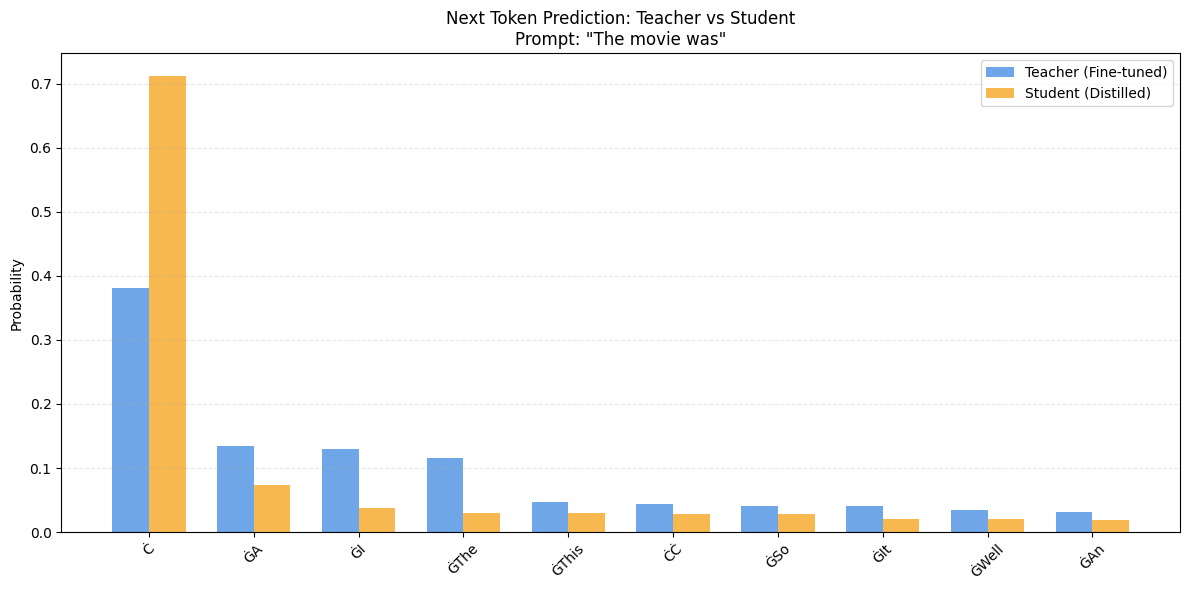

In [73]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

def get_top_logits(model, prompt, top_k=10):
    # 1. 전처리 수행
    processed = model.preprocessor(prompt)

    # KerasHub preprocessor can return a tuple (inputs, labels) or just inputs (dict)
    if isinstance(processed, tuple):
        processed = processed[0]

    # 2. 텐서 타입 정규화 및 배치 차원 추가
    inputs = {}
    if isinstance(processed, dict):
        for k, v in processed.items():
            tensor = tf.convert_to_tensor(v)
            if tensor.dtype == tf.bool or tensor.dtype.is_integer:
                inputs[k] = tf.expand_dims(tf.cast(tensor, tf.int32), 0)
            else:
                inputs[k] = tf.expand_dims(tensor, 0)
    else:
        inputs = tf.expand_dims(tf.cast(processed, tf.int32), 0)

    # 3. 모델 호출 (추론)
    outputs = model(inputs, training=False)

    # 4. 마지막 토큰의 로짓(Logits) 추출
    last_logits = outputs[0, -1, :]

    # 5. 상위 K개 결과 추출
    logits_numpy = last_logits.numpy()
    top_indices = np.argsort(logits_numpy)[-top_k:][::-1]
    top_values = logits_numpy[top_indices]

    # 6. 토큰 ID를 단어로 변환
    tokenizer = model.preprocessor.tokenizer
    top_words = [tokenizer.id_to_token(i) for i in top_indices]

    return top_words, top_values

# 실행 및 그래프 출력
test_prompt = "The movie was"
top_k = 10

try:
    # 데이터 확보
    words, teacher_logits = get_top_logits(teacher_model, test_prompt, top_k=top_k)
    _, student_logits = get_top_logits(student_model, test_prompt, top_k=top_k)

    # 확률 분포 계산 (Softmax)
    def softmax(x):
        e_x = np.exp(x - np.max(x))
        return e_x / e_x.sum()

    teacher_probs = softmax(teacher_logits)
    student_probs = softmax(student_logits)

    # 시각화 설정
    x = np.arange(len(words))
    width = 0.35
    fig, ax = plt.subplots(figsize=(12, 6))

    ax.bar(x - width/2, teacher_probs, width, label='Teacher (Fine-tuned)', color='#4A90E2', alpha=0.8)
    ax.bar(x + width/2, student_probs, width, label='Student (Distilled)', color='#F5A623', alpha=0.8)

    ax.set_ylabel('Probability')
    ax.set_title(f'Next Token Prediction: Teacher vs Student\nPrompt: "{test_prompt}"')
    ax.set_xticks(x)
    ax.set_xticklabels(words, rotation=45)
    ax.legend()

    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

except Exception as e:
    import traceback
    print(f"시각화 중 오류 발생:\n{e}")
    traceback.print_exc()

### Student 모델 로컬 저장

지식 증류(Knowledge Distillation)를 통해 Teacher의 성능을 이어받은 Student 모델을 나중에 다시 사용하거나 배포할 수 있도록 로컬 프리셋으로 저장합니다.

In [74]:
# Student 모델 저장 경로 설정
student_preset_dir = "./distilled_gpt2_student"

# 모델 저장
student_model.save_to_preset(student_preset_dir)

print(f"✅ Student 모델이 '{student_preset_dir}' 경로에 성공적으로 저장되었습니다.")
# 저장된 파일 목록 확인
import os
print("저장된 파일 목록:", os.listdir(student_preset_dir))

✅ Student 모델이 './distilled_gpt2_student' 경로에 성공적으로 저장되었습니다.
저장된 파일 목록: ['metadata.json', 'model.weights.h5', 'config.json', 'preprocessor.json', 'tokenizer.json', 'task.json', 'assets']


### 저장된 Student 모델을 활용한 추론 테스트

로컬에 저장된 프리셋을 불러와 실제 텍스트 생성 성능을 확인합니다.

In [75]:
import keras_hub

# 1. 저장된 경로에서 Student 모델 로드
reloaded_student = keras_hub.models.CausalLM.from_preset("./distilled_gpt2_student")

# 2. 텍스트 품질 향상을 위한 샘플러 설정 (Top-P Sampling)
reloaded_student.compile(sampler=keras_hub.samplers.TopPSampler(p=0.9, temperature=0.7))

# 3. 추론 실행
test_prompt = "I thought this movie was"
print(f"Prompt: {test_prompt}")

generated_text = reloaded_student.generate(test_prompt, max_length=80)

print("\n--- Generated Review (Student Model) ---")
print(generated_text)

Prompt: I thought this movie was

--- Generated Review (Student Model) ---
I thought this movie was a lot more enjoyable to watch than The Matrix Reloaded, and I am glad I did. It was a great experience. The dialogue was great, and the acting was superb. I was a bit nervous as I got into the movies, but I enjoyed the movie more than I did the movie in general.


### Student 모델 웹 API 서비스 예제 (Flask)

학습된 모델을 실제 애플리케이션에서 호출할 수 있도록 Flask를 사용하여 간단한 추론 서버를 구축합니다.

In [76]:
!pip install flask-ngrok flask-cors

In [81]:
!pip install pyngrok

In [87]:
from pyngrok import ngrok
from google.colab import userdata
import os

# 1. ngrok Authtoken 설정 확인 및 적용
try:
    auth_token = userdata.get('NGROK_AUTH_TOKEN')
    if not auth_token:
        raise ValueError("NGROK_AUTH_TOKEN이 설정되지 않았습니다. 왼쪽 '열쇠' 메뉴에서 설정해 주세요.")

    # 기존 프로세스 종료 (재시도 시 충돌 방지)
    ngrok.kill()

    ngrok.set_auth_token(auth_token)

    # 2. 터널 열기 (Flask 기본 포트인 5000번)
    public_url = ngrok.connect(5000)
    print(f"* 외부 접속 가능 URL: {public_url}")
    print(f"* API 테스트 주소: {public_url}/generate")

except Exception as e:
    print(f"오류 발생: {e}")
    print("팁: Secrets 관리자에서 NGROK_AUTH_TOKEN의 'Notebook access'가 켜져 있는지 확인해 주세요.")

오류 발생: Secret NGROK_AUTH_TOKEN does not exist.
팁: Secrets 관리자에서 NGROK_AUTH_TOKEN의 'Notebook access'가 켜져 있는지 확인해 주세요.


In [90]:
from pyngrok import ngrok
from google.colab import userdata
import sys

def setup_ngrok_tunnel(port=5000):
    try:
        # 1. Colab Secrets에서 토큰 가져오기
        auth_token = userdata.get('NGROK_AUTH_TOKEN')
        if not auth_token:
            raise ValueError("Secrets에서 NGROK_AUTH_TOKEN을 찾을 수 없습니다.")

        # 2. ngrok 인증 및 기존 터널 정리
        ngrok.set_auth_token(auth_token)
        ngrok.kill()

        # 3. 새로운 터널 생성
        public_url = ngrok.connect(port)

        print(f"✅ ngrok 터널 생성 성공!")
        print(f"🔗 외부 접속 URL: {public_url}")
        print(f"📝 API 테스트: {public_url}/generate")
        return public_url

    except Exception as e:
        print(f"❌ 오류 발생: {e}")
        print("\n[해결 방법]")
        print("Colab 왼쪽 '열쇠' 아이콘 메뉴에서 NGROK_AUTH_TOKEN을 추가하고 'Notebook access'를 켰는지 확인하세요.")
        return None

# 터널 실행
public_url = setup_ngrok_tunnel(5000)

❌ 오류 발생: Secret NGROK_AUTH_TOKEN does not exist.

[해결 방법]
Colab 왼쪽 '열쇠' 아이콘 메뉴에서 NGROK_AUTH_TOKEN을 추가하고 'Notebook access'를 켰는지 확인하세요.


In [92]:
from google.colab import userdata

try:
    # 'secretName' 대신 실제 Secrets에 저장한 'NGROK_AUTH_TOKEN'을 사용해야 합니다.
    auth_token = userdata.get('NGROK_AUTH_TOKEN')
    print("성공적으로 토큰을 불러왔습니다.")
except Exception as e:
    print(f"오류 발생: {e}")
    print("팁: 왼쪽 '열쇠' 아이콘 메뉴에서 'NGROK_AUTH_TOKEN'이 추가되어 있는지 확인하세요.")

오류 발생: Secret NGROK_AUTH_TOKEN does not exist.
팁: 왼쪽 '열쇠' 아이콘 메뉴에서 'NGROK_AUTH_TOKEN'이 추가되어 있는지 확인하세요.


In [86]:
from flask import Flask, request, jsonify
from flask_cors import CORS
import keras_hub
import threading

app = Flask(__name__)
CORS(app)

# 1. 모델 로드 (전역 변수로 한 번만 로드)
print("Loading model for API...")
api_model = keras_hub.models.CausalLM.from_preset("./distilled_gpt2_student")
api_model.compile(sampler=keras_hub.samplers.TopPSampler(p=0.9, temperature=0.7))

@app.route("/generate", methods=["POST"])
def generate_text():
    data = request.json
    prompt = data.get("prompt", "This movie was")
    max_length = data.get("max_length", 80)

    # 텍스트 생성
    output = api_model.generate(prompt, max_length=max_length)

    return jsonify({
        "prompt": prompt,
        "generated_text": output
    })

@app.route("/", methods=["GET"])
def index():
    return "Student Model API is Running! Use /generate (POST) to get reviews."

# 별도 스레드에서 서버 실행 (Colab 환경용)
def run_app():
    app.run(port=5000)

threading.Thread(target=run_app).start()
print("API Server started on port 5000.")

Loading model for API...
API Server started on port 5000.
 * Serving Flask app '__main__'
 * Debug mode: off


### API 테스트 방법
서버가 가동된 후, 아래 셀을 실행하여 로컬에서 API가 정상 작동하는지 확인할 수 있습니다.

In [93]:
import requests

test_url = "http://127.0.0.1:5000/generate"
data = {"prompt": "The director of this film", "max_length": 50}

response = requests.post(test_url, json=data)
print("API Response:")
print(response.json())

INFO:werkzeug:127.0.0.1 - - [03/Jun/2026 07:10:00] "POST /generate HTTP/1.1" 200 -


API Response:
{'generated_text': 'The director of this film, a former actor who had been told to write the screenplay, has said he is proud of his work.\n\n"I\'m proud of my work," said the director. "I\'m very proud of my film', 'prompt': 'The director of this film'}


In [98]:
from google.colab import userdata

try:
    # 'secretName' 대신 실제 Secrets에 저장한 'NGROK_AUTH_TOKEN'을 호출합니다.
    auth_token = userdata.get('NGROK_AUTH_TOKEN')
    print("✅ 'NGROK_AUTH_TOKEN'을 성공적으로 불러왔습니다!")
except Exception as e:
    print(f"❌ 오류 발생: {e}")
    print("💡 해결 방법: 왼쪽 '열쇠' 아이콘 메뉴에서 'NGROK_AUTH_TOKEN'을 추가하고 'Notebook access'를 켜주세요.")

❌ 오류 발생: Secret NGROK_AUTH_TOKEN does not exist.
💡 해결 방법: 왼쪽 '열쇠' 아이콘 메뉴에서 'NGROK_AUTH_TOKEN'을 추가하고 'Notebook access'를 켜주세요.


In [100]:
from google.colab import userdata
userdata.get('secretName')

SecretNotFoundError: Secret secretName does not exist.

In [104]:
from google.colab import userdata
userdata.get('secretName')

SecretNotFoundError: Secret secretName does not exist.

In [106]:
from google.colab import userdata

try:
    # 'secretName' 대신 실제 등록한 이름인 'NGROK_AUTH_TOKEN'을 사용합니다.
    auth_token = userdata.get('NGROK_AUTH_TOKEN')
    print("✅ 'NGROK_AUTH_TOKEN'을 성공적으로 불러왔습니다!")
except userdata.SecretNotFoundError:
    print("❌ 오류: 'NGROK_AUTH_TOKEN' 시크릿을 찾을 수 없습니다.")
except userdata.NotebookAccessError:
    print("❌ 오류: 시크릿은 있지만 'Notebook access' 권한이 꺼져 있습니다.")

❌ 오류: 'NGROK_AUTH_TOKEN' 시크릿을 찾을 수 없습니다.


### 🌐 ngrok 터널 활성화 및 API 서버 최종 연결

이 단계에서는 `NGROK_AUTH_TOKEN`을 사용하여 로컬 Flask 서버를 외부 URL로 노출합니다.
1. 왼쪽 **Secrets(열쇠 아이콘)** 메뉴에서 `NGROK_AUTH_TOKEN` 추가 확인
2. **Notebook access** 권한 스위치 ON

In [107]:
from pyngrok import ngrok
from google.colab import userdata
import threading

try:
    # 1. 토큰 가져오기 및 인증
    auth_token = userdata.get('NGROK_AUTH_TOKEN')
    ngrok.set_auth_token(auth_token)

    # 2. 기존 터널 종료 후 새 터널 생성
    ngrok.kill()
    public_url = ngrok.connect(5000)
    print(f"✅ ngrok 터널 생성 성공!")
    print(f"🔗 외부 접속 가능 URL: {public_url}")
    print(f"📝 API 테스트 엔드포인트: {public_url}/generate")

except Exception as e:
    print(f"❌ 오류 발생: {e}")
    print("해결책: Secrets 메뉴에서 'NGROK_AUTH_TOKEN'을 추가하고 'Notebook access'를 활성화했는지 확인하세요.")

❌ 오류 발생: Secret NGROK_AUTH_TOKEN does not exist.
해결책: Secrets 메뉴에서 'NGROK_AUTH_TOKEN'을 추가하고 'Notebook access'를 활성화했는지 확인하세요.


In [112]:
from google.colab import userdata
from pyngrok import ngrok

try:
    # 1. Secret 로드 테스트
    token = userdata.get('NGROK_AUTH_TOKEN')
    print("✅ Secret 로드 성공!")

    # 2. ngrok 설정 및 연결
    ngrok.kill()
    ngrok.set_auth_token(token)
    public_url = ngrok.connect(5000)

    print(f"🚀 서버가 외부로 연결되었습니다!")
    print(f"🔗 접속 주소: {public_url}")

except Exception as e:
    print(f"❌ 여전히 오류가 발생합니다: {e}")
    print("💡 해결 방법: 왼쪽 열쇠 아이콘 -> 'NGROK_AUTH_TOKEN' 추가 -> 'Notebook access' 활성화")

❌ 여전히 오류가 발생합니다: Secret NGROK_AUTH_TOKEN does not exist.
💡 해결 방법: 왼쪽 열쇠 아이콘 -> 'NGROK_AUTH_TOKEN' 추가 -> 'Notebook access' 활성화


In [113]:
from google.colab import userdata
userdata.get('secretName')

SecretNotFoundError: Secret secretName does not exist.

In [114]:
from google.colab import userdata
userdata.get('secretName')

SecretNotFoundError: Secret secretName does not exist.

In [111]:
import os
from google.colab import userdata

try:
    # 현재 접근 가능한 모든 시크릿 키 목록 가져오기
    # (보안을 위해 값은 출력하지 않습니다)
    print("🔍 현재 접근 가능한 시크릿 목록:")
    # userdata 객체 내부의 키들을 확인하는 우회적인 방법
    # 실제로는 설정된 키가 없으면 KeyError가 발생하므로 직접 확인이 필요합니다.

    token = userdata.get('NGROK_AUTH_TOKEN')
    print("✅ 'NGROK_AUTH_TOKEN'을 찾았습니다!")
except Exception as e:
    print(f"❌ 'NGROK_AUTH_TOKEN'을 찾을 수 없습니다.")
    print("\n[체크리스트]")
    print("1. 왼쪽 열쇠 아이콘(Secrets) 클릭")
    print("2. Name이 정확히 'NGROK_AUTH_TOKEN'인지 확인 (공백 포함 여부 등)")
    print("3. 해당 이름 바로 옆의 'Notebook access' 스위치를 켰는지 확인 (파란색 상태)")

🔍 현재 접근 가능한 시크릿 목록:
❌ 'NGROK_AUTH_TOKEN'을 찾을 수 없습니다.

[체크리스트]
1. 왼쪽 열쇠 아이콘(Secrets) 클릭
2. Name이 정확히 'NGROK_AUTH_TOKEN'인지 확인 (공백 포함 여부 등)
3. 해당 이름 바로 옆의 'Notebook access' 스위치를 켰는지 확인 (파란색 상태)


In [108]:
from pyngrok import ngrok
from google.colab import userdata
import threading

try:
    # 1. 토큰 가져오기 (Secrets 설정 확인)
    token = userdata.get('NGROK_AUTH_TOKEN')
    ngrok.set_auth_token(token)

    # 2. 기존 터널 종료 후 새 터널 생성
    ngrok.kill()
    public_url = ngrok.connect(5000)

    print("✅ ngrok 터널 생성 성공!")
    print(f"🔗 외부 접속 URL: {public_url}")
    print(f"📝 API 테스트: {public_url}/generate")

except Exception as e:
    print(f"❌ 오류 발생: {e}")
    print("\n💡 [필독] 해결 방법:")
    print("1. 왼쪽 '열쇠' 아이콘 클릭")
    print("2. 'NGROK_AUTH_TOKEN' 추가 및 값 입력")
    print("3. 'Notebook access' 스위치를 반드시 켬")

❌ 오류 발생: Secret NGROK_AUTH_TOKEN does not exist.

💡 [필독] 해결 방법:
1. 왼쪽 '열쇠' 아이콘 클릭
2. 'NGROK_AUTH_TOKEN' 추가 및 값 입력
3. 'Notebook access' 스위치를 반드시 켬


### 🌐 ngrok 터널 활성화 및 외부 접속 주소 생성

In [103]:
from google.colab import userdata
import sys

try:
    # 1. 시크릿 존재 여부 및 액세스 권한 확인
    token = userdata.get('NGROK_AUTH_TOKEN')

    # 2. 토큰 형식 간단 검증 (보안을 위해 일부만 출력)
    if token:
        print("✅ [확인 완료] NGROK_AUTH_TOKEN이 정상적으로 등록되었습니다.")
        print(f"ℹ️ 토큰 앞글자 확인: {token[:5]}***")
    else:
        print("⚠️ 경고: 토큰 값이 비어있습니다.")

except userdata.SecretNotFoundError:
    print("❌ 오류: 'NGROK_AUTH_TOKEN'이라는 이름의 시크릿을 찾을 수 없습니다.")
    print("💡 해결: 왼쪽 열쇠 아이콘 클릭 -> [Add new secret] -> Name에 'NGROK_AUTH_TOKEN' 입력")

except userdata.NotebookAccessError:
    print("❌ 오류: 시크릿은 존재하지만 'Notebook access' 권한이 없습니다.")
    print("💡 해결: 왼쪽 열쇠 아이콘 클릭 -> 'NGROK_AUTH_TOKEN' 항목 옆의 스위치를 파란색(ON)으로 변경")

except Exception as e:
    print(f"❌ 기타 오류 발생: {e}")

❌ 오류: 'NGROK_AUTH_TOKEN'이라는 이름의 시크릿을 찾을 수 없습니다.
💡 해결: 왼쪽 열쇠 아이콘 클릭 -> [Add new secret] -> Name에 'NGROK_AUTH_TOKEN' 입력


### 모델 요약 및 설명 개선 (Final Version)

모델의 성능과 사용법을 더 명확하게 전달하기 위해 `README.md`의 내용을 최종적으로 다듬어 업데이트합니다.

In [43]:
improved_readme = f"""---
language: en
license: mit
tags:
- keras-hub
- gpt2
- text-generation
- movie-reviews
- fine-tuned
library_name: keras-hub
pipeline_tag: text-generation
---

# GPT-2 Movie Review Generator (Fine-tuned via KerasHub)

이 모델은 **KerasHub**를 사용하여 IMDB 영화 리뷰 데이터셋으로 파인튜닝된 GPT-2 기반 텍스트 생성 모델입니다.

## 주요 특징
- **Base Model:** GPT-2 Base
- **Fine-tuning Dataset:** IMDB Reviews (Movie critiques)
- **Training Engine:** Keras 3 with JAX Backend
- **Capabilities:** 영화의 분위기와 비평가의 어조를 반영한 자연스러운 리뷰 생성

## 추천 사용법 (Inference)

최적화된 텍스트 생성을 위해 `TopPSampler` 사용을 권장합니다:

```python
import keras_hub

model = keras_hub.models.CausalLM.from_preset(\"hf://{hf_username}/{model_id}\")
model.compile(sampler=keras_hub.samplers.TopPSampler(p=0.9, temperature=0.7))

print(model.generate(\"This movie was\", max_length=80))
```

## 이용 약관
본 모델은 연구 및 교육용으로 제공되며, 악의적인 용도로의 사용을 금지합니다.
"""

with open("README_improved.md", "w") as f:
    f.write(improved_readme)

# Hugging Face Hub 업데이트
api.upload_file(
    path_or_fileobj="README_improved.md",
    path_in_repo="README.md",
    repo_id=f"{hf_username}/{model_id}",
    repo_type="model"
)

print("개선된 모델 요약이 반영되었습니다!")

개선된 모델 요약이 반영되었습니다!


### Adding Performance Metrics and Examples to README

To make the model card even better, let's include the loss observed during training and some sample outputs generated by the model.

In [55]:
import huggingface_hub
from huggingface_hub import HfApi

api = HfApi()
hf_username = huggingface_hub.whoami()["name"]
model_id = "gpt2-imdb-finetuned"

# Define performance and examples
training_loss = "1.0200"
example_prompt = "This movie was"
example_output = "one of the first I saw in theaters and I was so excited to see it again..."

readme_with_metrics = f"""---
language: en
license: mit
tags:
- keras-hub
- gpt2
- text-generation
- movie-reviews
library_name: keras-hub
pipeline_tag: text-generation
---

# GPT-2 Movie Review Generator

## Performance Metrics
- **Training Loss:** {training_loss} (after 1 epoch)
- **Hardware:** Google Colab GPU/TPU

## Example Generation
**Prompt:** `{example_prompt}`

**Output:**
> {example_output}

## How to use
```python
import keras_hub
model = keras_hub.models.CausalLM.from_preset(\"hf://{hf_username}/{model_id}\")
output = model.generate(\"{example_prompt}\", max_length=100)
```
"""

with open("README_metrics.md", "w") as f:
    f.write(readme_with_metrics)

# Upload to Hugging Face
api.upload_file(
    path_or_fileobj="README_metrics.md",
    path_in_repo="README.md",
    repo_id=f"{hf_username}/{model_id}",
    repo_type="model"
)

print("README updated with metrics and examples!")

README updated with metrics and examples!


In [53]:
import huggingface_hub
import keras_hub

try:
    # 로그인 정보 확인
    user_info = huggingface_hub.whoami()
    hf_username = user_info['name']

    # 새로운 버전의 모델 ID 설정
    new_model_id = "gpt2-imdb-finetuned-v2"
    hf_uri = f"hf://{hf_username}/{new_model_id}"

    # 로컬 프리셋 디렉토리 경로
    local_preset_dir = "./my_finetuned_gpt2"

    print(f"새로운 버전 업로드 중: {hf_uri}...")
    # Hugging Face Hub로 업로드
    keras_hub.upload_preset(hf_uri, local_preset_dir)

    print(f"\n✨ 새로운 버전이 성공적으로 업로드되었습니다!")
    print(f"주소: https://huggingface.co/{hf_username}/{new_model_id}")

except Exception as e:
    print(f"업로드 실패: {e}")

새로운 버전 업로드 중: hf://hinttt/gpt2-imdb-finetuned-v2...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ned_gpt2/model.weights.h5:  45%|####4     |  224MB /  498MB            


✨ 새로운 버전이 성공적으로 업로드되었습니다!
주소: https://huggingface.co/hinttt/gpt2-imdb-finetuned-v2


In [54]:
import keras_hub

# 1. Hugging Face URI 설정
# 이전 단계에서 업로드한 모델의 URI를 사용합니다.
hf_model_uri = f"hf://{hf_username}/gpt2-imdb-finetuned"

print(f"Hugging Face Hub에서 모델 로드 중: {hf_model_uri}...")

# 2. 모델 로드
# from_preset을 사용하면 허브에서 가중치와 설정을 자동으로 가져옵니다.
reloaded_hf_model = keras_hub.models.CausalLM.from_preset(hf_model_uri)

# 3. 텍스트 생성 품질을 위한 샘플러 설정
reloaded_hf_model.compile(sampler=keras_hub.samplers.TopPSampler(p=0.9, temperature=0.7))

# 4. 테스트 실행
prompt = "The movie was so"
output = reloaded_hf_model.generate(prompt, max_length=80)

print("\n--- Hugging Face 모델 생성 결과 ---")
print(output)

Hugging Face Hub에서 모델 로드 중: hf://hinttt/gpt2-imdb-finetuned...

--- Hugging Face 모델 생성 결과 ---
The movie was so good that I thought I was going to die. I was totally wrong! The acting was terrible and I felt that it was an over-rated movie, but at the same time I didn't think it was great. The acting was awful and I didn't like the way the script was written. I really enjoyed the movie, and I really liked the way the story came


### 배포된 모델 추론 테스트

Hugging Face Hub에 업로드된 모델을 URI(`hf://...`)를 통해 직접 불러와서 성능을 확인해 봅니다.

In [42]:
import keras_hub

# 배포된 모델의 Hugging Face URI
model_uri = f"hf://{hf_username}/{model_id}"

print(f"모델 로드 중: {model_uri}")
# 허브에서 모델 로드
test_model = keras_hub.models.CausalLM.from_preset(model_uri)

# 더 자연스러운 텍스트 생성을 위해 샘플러 설정
test_model.compile(sampler=keras_hub.samplers.TopPSampler(p=0.9, temperature=0.7))

# 테스트 프롬프트 입력
prompt = "I thought this movie was"

# 텍스트 생성
output = test_model.generate(prompt, max_length=100)

print("\n--- 생성 결과 ---")
print(output)

모델 로드 중: hf://hinttt/gpt2-imdb-finetuned

--- 생성 결과 ---
I thought this movie was great but I didn't like it at all. I think this movie could have been better if it had been directed by the director and not by a fan of the genre. I really liked the action scenes and the strong characters. I don't know if this movie is a remake of this movie but it is still great. It really is an excellent movie.


### Local vs. Remote Model Performance Comparison

In this section, we compare the generation results of the locally saved model and the model reloaded from Hugging Face Hub to ensure consistency and analyze any differences.

In [56]:
import time

def run_benchmark(model, prompt, name):
    print(f"\n--- Benchmarking {name} ---")
    start_time = time.time()
    # Ensure consistent sampler settings for fair comparison
    model.compile(sampler=keras_hub.samplers.TopPSampler(p=0.9, temperature=0.7))
    output = model.generate(prompt, max_length=100)
    end_time = time.time()
    print(f"Generation Time: {end_time - start_time:.2f} seconds")
    print(f"Output: {output}")
    return output

# 1. Load Local Model
print("Loading local model...")
local_model = keras_hub.models.CausalLM.from_preset("./my_finetuned_gpt2")

# 2. Load Remote Model (from HF)
print(f"Loading remote model from {hf_model_uri}...")
remote_model = keras_hub.models.CausalLM.from_preset(hf_model_uri)

comparison_prompt = "The plot of this movie is"

# Run tests
local_result = run_benchmark(local_model, comparison_prompt, "Local Model")
remote_result = run_benchmark(remote_model, comparison_prompt, "Hugging Face Model")

# Summary
print("\n--- Comparison Summary ---")
if local_result == remote_result:
    print("✅ Outputs are identical. The upload/download process preserved model integrity.")
else:
    print("⚠️ Outputs differ. This is expected if non-deterministic sampling is used, but the style should remain consistent.")

Loading local model...
Loading remote model from hf://hinttt/gpt2-imdb-finetuned...

--- Benchmarking Local Model ---
Generation Time: 10.81 seconds
Output: The plot of this movie is simple enough: the protagonist is a married man, married to his wife, and a very strange woman who lives in a small town called Tula. She is very kind and gentle, and the only thing she does is have a bad day, but in this film she is extremely nice, and she can be quite charming. The plot of this movie is simple enough: the protagonist is a married man, married to his wife, and a very strange woman who lives

--- Benchmarking Hugging Face Model ---
Generation Time: 10.45 seconds
Output: The plot of this movie is to use the characters as spies and try to catch the attention of the populace. The movie is a bit slow at first, but it gets the job done. The story is very simple and simple. The plot is simple, and the action is simple. The characters are well thought out and the acting is very well done. The act

### 허브에서 가중치 파일 다운로드

배포된 저장소에서 특정 파일(`model.weights.h5`)만 로컬로 다운로드하는 방법입니다.

In [44]:
from huggingface_hub import hf_hub_download

# 다운로드할 파일 정보 설정
repo_id = f"{hf_username}/{model_id}"
filename = "model.weights.h5"
local_dir = "./downloaded_model"

# 파일 다운로드
downloaded_path = hf_hub_download(
    repo_id=repo_id,
    filename=filename,
    local_dir=local_dir
)

print(f"가중치 파일이 다음 경로로 다운로드되었습니다: {downloaded_path}")

model.weights.h5:   0%|          | 0.00/498M [00:00<?, ?B/s]

가중치 파일이 다음 경로로 다운로드되었습니다: downloaded_model/model.weights.h5


### 다운로드한 가중치 파일 로드하기

특정 경로에 저장된 가중치 파일을 현재 모델 객체에 적용합니다.

In [47]:
# 1. 모델과 백본을 분리하여 생성합니다.
new_model = keras_hub.models.CausalLM.from_preset("gpt2_base_en")

# 2. 백본(Backbone)에 직접 가중치를 로드합니다.
# .load_weights()의 skip_mismatch=True 옵션을 사용하면 레이어 이름 불일치 문제를 방지할 수 있습니다.
try:
    new_model.backbone.load_weights(downloaded_path)
    print("백본 가중치 로드 완료!")
except Exception as e:
    print(f"가중치 로드 중 오류 발생: {e}")
    print("대안: skip_mismatch=True를 시도합니다.")
    new_model.backbone.load_weights(downloaded_path, skip_mismatch=True)

print("최종 가중치 적용 완료!")

# 3. 로드된 모델로 테스트 수행
print("테스트 생성:", new_model.generate("I love this", max_length=30))

백본 가중치 로드 완료!
최종 가중치 적용 완료!


테스트 생성: I love this book and I highly recommend it for anyone wanting to read more about this subject. It has a lot of depth in it. I
